# M3 — Segmentation client

Créer des clusters de clients basés sur l'âge, les dépenses et les produits achetés (K-means, PCA, t-SNE, clustering hiérarchique).

> ⚠️ Échantillon de 5 clients : le clustering ci-dessous illustre le pipeline complet, mais le nombre de clusters et leur stabilité ne seront réellement interprétables qu'avec un volume de données plus important.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from src.data_loader import load_sales_with_context

df = load_sales_with_context()
df.head()

,Sale_ID,Product_ID,Customer_ID,Date,Quantity,Sale_Price,Channel,Name,Age,Gender,Location,Join_Date,Total_Spent,Product_Name,Category,Price,Brand
0,1,101,2001,2023-01-15,2,50.0,Online,Alice,28,Female,New York,2022-05-10,500.0,T-shirt,Clothing,25.0,Brand A
1,2,102,2002,2023-01-16,1,75.0,In-Store,Bob,35,Male,Los Angeles,2022-06-15,750.0,Jeans,Clothing,75.0,Brand B
2,3,103,2001,2023-01-17,3,30.0,Online,Alice,28,Female,New York,2022-05-10,500.0,Sneakers,Footwear,30.0,Brand C
3,4,104,2003,2023-01-18,1,120.0,In-Store,Charlie,22,Male,Chicago,2022-07-20,300.0,Jacket,Outerwear,120.0,Brand D
4,5,105,2004,2023-01-19,2,45.0,Online,Diana,30,Female,Houston,2022-08-25,600.0,Hat,Accessories,22.5,Brand E


## Préparation des features (âge, dépenses, nombre d'achats, catégorie préférée)

In [2]:
features = df.groupby("Customer_ID").agg(
    Age=("Age", "first"),
    Total_Spent=("Total_Spent", "first"),
    Nb_Achats=("Sale_ID", "count"),
).reset_index()
top_category = (
    df.groupby(["Customer_ID", "Category"]).size().reset_index(name="n")
    .sort_values("n", ascending=False).drop_duplicates("Customer_ID")
    [["Customer_ID", "Category"]].rename(columns={"Category": "Categorie_Preferee"})
)
features = features.merge(top_category, on="Customer_ID")
features

,Customer_ID,Age,Total_Spent,Nb_Achats,Categorie_Preferee
0,2001,28,500.0,2,Clothing
1,2002,35,750.0,1,Clothing
2,2003,22,300.0,1,Outerwear
3,2004,30,600.0,1,Accessories


## K-means (n_clusters=3, choisi arbitrairement compte tenu du faible échantillon)

In [3]:
n_clusters = min(3, len(features))
X = StandardScaler().fit_transform(features[["Age", "Total_Spent", "Nb_Achats"]])
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
features["Cluster"] = kmeans.fit_predict(X)
features

,Customer_ID,Age,Total_Spent,Nb_Achats,Categorie_Preferee,Cluster
0,2001,28,500.0,2,Clothing,2
1,2002,35,750.0,1,Clothing,0
2,2003,22,300.0,1,Outerwear,1
3,2004,30,600.0,1,Accessories,0


## Clustering hiérarchique (comparaison)

In [4]:
hier = AgglomerativeClustering(n_clusters=n_clusters)
features["Cluster_Hierarchique"] = hier.fit_predict(X)
features[["Customer_ID", "Cluster", "Cluster_Hierarchique"]]

,Customer_ID,Cluster,Cluster_Hierarchique
0,2001,2,2
1,2002,0,0
2,2003,1,1
3,2004,0,0


## Réduction de dimension (PCA) pour visualisation

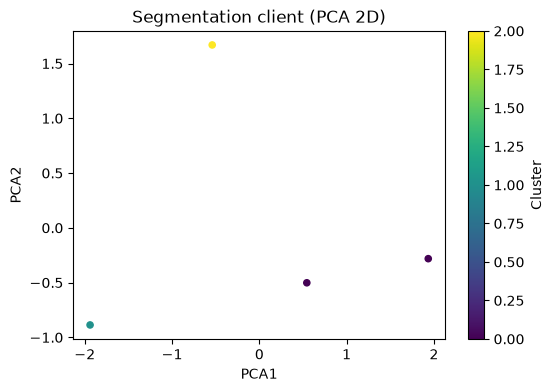

In [5]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X)
features[["PCA1", "PCA2"]] = coords
ax = features.plot.scatter(x="PCA1", y="PCA2", c="Cluster", colormap="viridis", figsize=(6, 4), title="Segmentation client (PCA 2D)")
ax.figure.savefig("../reports/M3_segmentation_pca.png", dpi=120, bbox_inches="tight")

## Export des segments pour M4 (profilage)

In [6]:
from pathlib import Path
Path("../data/processed").mkdir(parents=True, exist_ok=True)
features.to_csv("../data/processed/segments.csv", index=False)
print("Segments exportés vers data/processed/segments.csv")

Segments exportés vers data/processed/segments.csv
